# Station 2348 Offday Pattern + Month Weight + Ridge

이 노트북은 다음 아이디어를 반영합니다.

- 토요일, 일요일, 공휴일은 `offday`로 묶음
- 평일은 `weekday`, 비근무일은 `offday`로 구분
- 예측값은 `0 이상 실수`로만 제한하고 정수 반올림은 하지 않음
- `day_type`별 시간 기본 패턴 회귀식을 먼저 만듦
- 월별로는 패턴 모양보다 규모 차이로 보고 `month_weight`를 계산
- `day_type` 패턴과 `month_weight`를 결합한 `pattern_prior`를 Ridge가 학습

분할:
- Train: 2023년
- Valid: 2024년
- Test: 2025년

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_DIR = Path('../Data')
INPUT_PATH = DATA_DIR / 'station_raw/station_2348.csv'
target_cols = ['rental_count', 'return_count']
day_type_order = ['weekday', 'offday']

df = pd.read_csv(INPUT_PATH)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
df['date'] = df['time'].dt.normalize()

display(df.head())
print(f'rows: {len(df):,}')
print(f'time range: {df["time"].min()} ~ {df["time"].max()}')
display(df[target_cols + ['bike_change']].describe().T)


,station_id,time,rental_count,return_count,bike_change,bike_count_index,year,month,day,weekday,hour,date
0,2348,2023-01-01 00:00:00,0,0,0,0,2023,1,1,6,0,2023-01-01
1,2348,2023-01-01 01:00:00,0,2,2,2,2023,1,1,6,1,2023-01-01
2,2348,2023-01-01 02:00:00,1,1,0,2,2023,1,1,6,2,2023-01-01
3,2348,2023-01-01 03:00:00,0,0,0,2,2023,1,1,6,3,2023-01-01
4,2348,2023-01-01 04:00:00,0,0,0,2,2023,1,1,6,4,2023-01-01


rows: 26,304
time range: 2023-01-01 00:00:00 ~ 2025-12-31 23:00:00


,count,mean,std,min,25%,50%,75%,max
rental_count,"26,304.0000",1.7143,3.0681,0.0000,0.0000,1.0000,2.0000,36.0000
return_count,"26,304.0000",2.1720,3.9931,0.0000,0.0000,1.0000,2.0000,43.0000
bike_change,"26,304.0000",0.4578,4.3768,-28.0000,-1.0000,0.0000,1.0000,41.0000


In [2]:
holiday_source_paths = [
    Path('../../works/archive_legacy/03_prediction/02_data/ddri_station_day_train_baseline_dataset.csv'),
    Path('../../works/archive_legacy/03_prediction/02_data/ddri_station_day_test_main_eval_dataset.csv'),
]

holiday_frames = []
for path in holiday_source_paths:
    if path.exists():
        temp = pd.read_csv(path, usecols=['date', 'is_holiday', 'holiday_name'])
        temp = temp[temp['is_holiday'] == 1].copy()
        temp['date'] = pd.to_datetime(temp['date']).dt.normalize()
        holiday_frames.append(temp[['date', 'holiday_name']].drop_duplicates())

if holiday_frames:
    holiday_df = pd.concat(holiday_frames, ignore_index=True).drop_duplicates().sort_values('date').reset_index(drop=True)
    holiday_source = 'workspace holiday datasets'
else:
    holiday_df = pd.DataFrame({'date': pd.to_datetime([], utc=False), 'holiday_name': []})
    holiday_source = 'not found'

holiday_set = set(holiday_df['date'])

df = df.merge(holiday_df.rename(columns={'holiday_name': 'holiday_name_src'}), on='date', how='left')
df['is_holiday'] = df['date'].isin(holiday_set).astype(int)
df['is_offday'] = ((df['weekday'] >= 5) | (df['is_holiday'] == 1)).astype(int)
df['day_type'] = np.where(df['is_offday'] == 1, 'offday', 'weekday')
df['day_type'] = pd.Categorical(df['day_type'], categories=day_type_order, ordered=True)

print(f'holiday source: {holiday_source}')
display(holiday_df.head(20))
display(df[['time', 'weekday', 'is_holiday', 'holiday_name_src', 'day_type']].head(24))
print(df['day_type'].value_counts(dropna=False))


holiday source: workspace holiday datasets


,date,holiday_name
0,2023-01-01,1월1일
1,2023-01-21,설날
2,2023-01-22,설날
3,2023-01-23,설날
4,2023-01-24,대체공휴일
5,2023-03-01,삼일절
6,2023-05-05,어린이날
7,2023-05-27,부처님오신날
8,2023-05-29,대체공휴일
9,2023-06-06,현충일


,time,weekday,is_holiday,holiday_name_src,day_type
0,2023-01-01 00:00:00,6,1,1월1일,offday
1,2023-01-01 01:00:00,6,1,1월1일,offday
2,2023-01-01 02:00:00,6,1,1월1일,offday
3,2023-01-01 03:00:00,6,1,1월1일,offday
4,2023-01-01 04:00:00,6,1,1월1일,offday
5,2023-01-01 05:00:00,6,1,1월1일,offday
6,2023-01-01 06:00:00,6,1,1월1일,offday
7,2023-01-01 07:00:00,6,1,1월1일,offday
8,2023-01-01 08:00:00,6,1,1월1일,offday
9,2023-01-01 09:00:00,6,1,1월1일,offday


day_type
weekday    17688
offday      8616
Name: count, dtype: int64


C:\Users\TJ\AppData\Local\Temp\ipykernel_676\139930452.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daytype_hour = df.groupby(['day_type', 'hour'])[target].mean().reset_index()
C:\Users\TJ\AppData\Local\Temp\ipykernel_676\139930452.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daytype_hour = df.groupby(['day_type', 'hour'])[target].mean().reset_index()


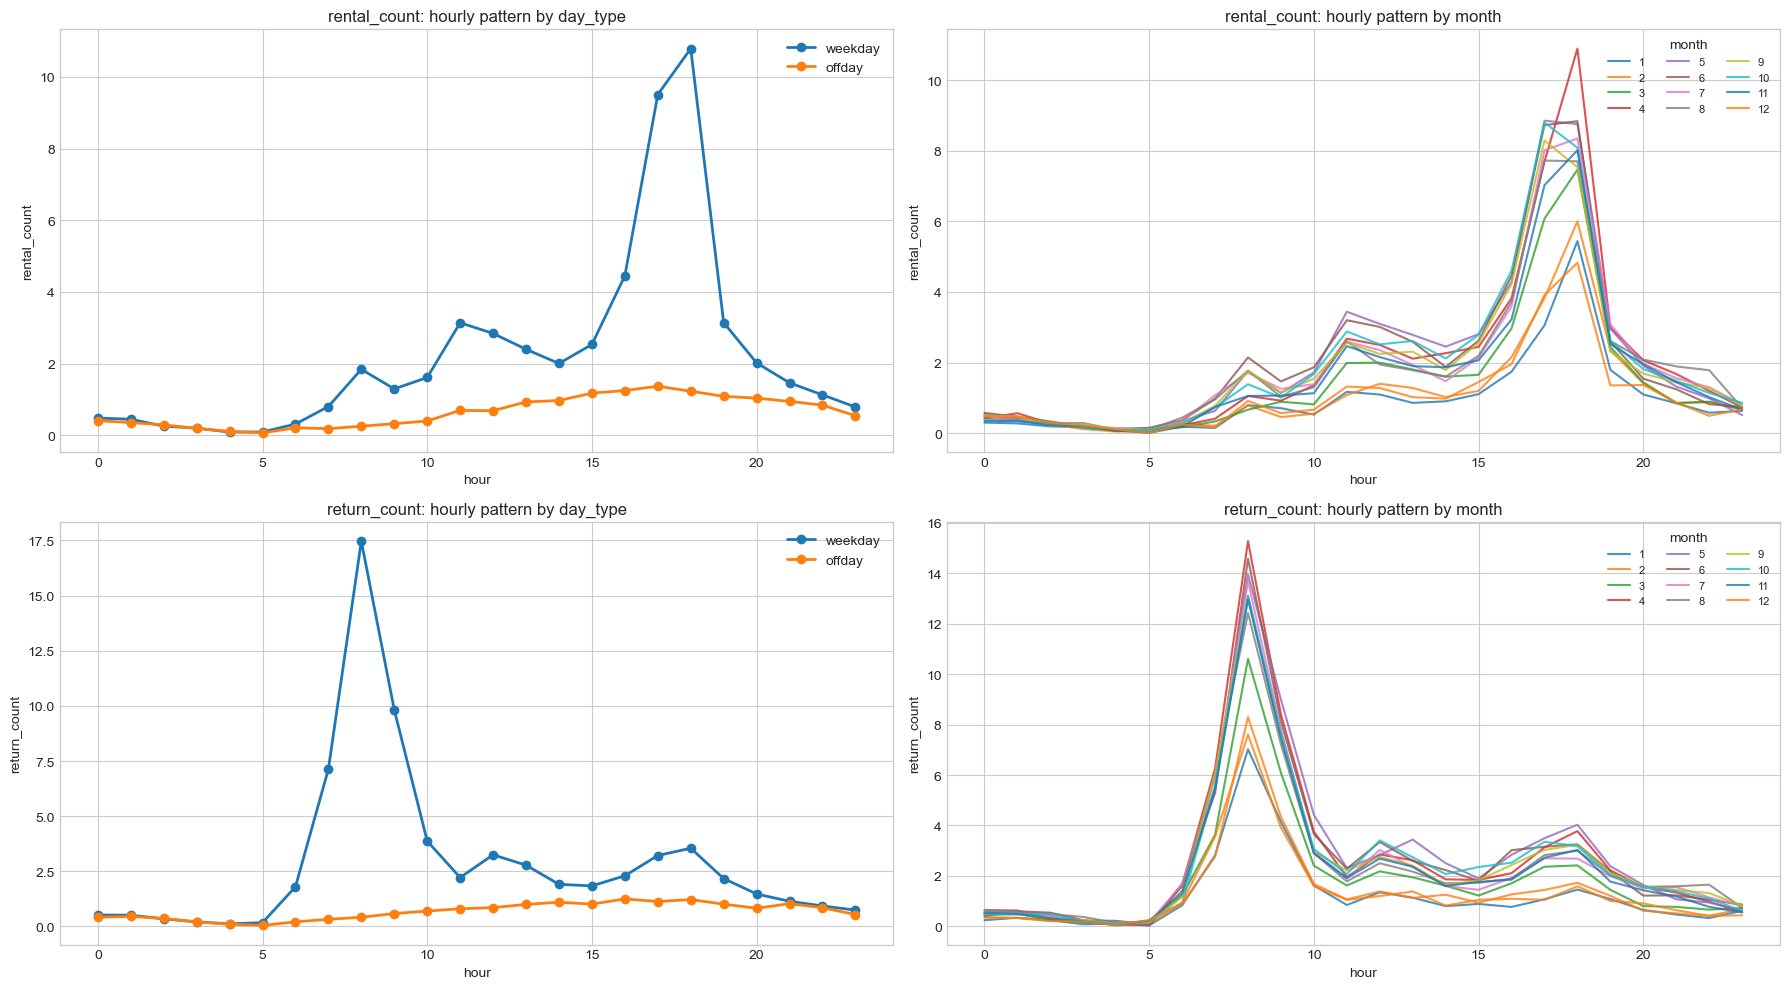

In [3]:
fig, axes = plt.subplots(len(target_cols), 2, figsize=(18, 5 * len(target_cols)))

for row_idx, target in enumerate(target_cols):
    daytype_hour = df.groupby(['day_type', 'hour'])[target].mean().reset_index()
    for day_type in day_type_order:
        sub = daytype_hour[daytype_hour['day_type'] == day_type]
        axes[row_idx, 0].plot(sub['hour'], sub[target], marker='o', linewidth=2, label=day_type)
    axes[row_idx, 0].set_title(f'{target}: hourly pattern by day_type')
    axes[row_idx, 0].set_xlabel('hour')
    axes[row_idx, 0].set_ylabel(target)
    axes[row_idx, 0].legend()

    month_hour = df.groupby(['month', 'hour'])[target].mean().reset_index()
    for month in sorted(month_hour['month'].unique()):
        sub = month_hour[month_hour['month'] == month]
        axes[row_idx, 1].plot(sub['hour'], sub[target], linewidth=1.5, alpha=0.8, label=str(month))
    axes[row_idx, 1].set_title(f'{target}: hourly pattern by month')
    axes[row_idx, 1].set_xlabel('hour')
    axes[row_idx, 1].set_ylabel(target)
    axes[row_idx, 1].legend(title='month', ncol=3, fontsize=8)

plt.tight_layout()
plt.show()


## Pattern Construction

패턴 특징은 아래 순서로 만듭니다.

1. `day_type`별 시간 평균을 사인/코사인 회귀식으로 근사하여 `base_value` 생성
2. `base_value` 대비 월별 평균 비율을 계산하여 `month_weight` 생성
3. `pattern_prior = base_value * month_weight`
4. Ridge는 `base_value`, `month_weight`, `pattern_prior`와 시간 주기 특성을 함께 학습

In [4]:
def non_negative_only(y_pred):
    return np.clip(y_pred, 0, None)


def calc_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


def fit_day_type_hour_models(train_df, target):
    formula_rows = []
    base_rows = []
    for day_type in day_type_order:
        sub = train_df[train_df['day_type'] == day_type].groupby('hour')[target].mean().reset_index()
        angle = 2 * np.pi * sub['hour'].to_numpy(dtype=float) / 24.0
        X = np.column_stack([np.ones(len(sub)), np.sin(angle), np.cos(angle)])
        y = sub[target].to_numpy(dtype=float)
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        sub['base_value'] = np.clip(X @ beta, 0, None)
        sub['day_type'] = day_type
        base_rows.append(sub[['day_type', 'hour', 'base_value']])
        formula_rows.append({
            'target': target,
            'day_type': day_type,
            'intercept': beta[0],
            'sin_hour_coef': beta[1],
            'cos_hour_coef': beta[2],
            'formula': f'{beta[0]:.6f} + ({beta[1]:+.6f} * sin(2pi*hour/24)) + ({beta[2]:+.6f} * cos(2pi*hour/24))',
        })
    return pd.DataFrame(formula_rows), pd.concat(base_rows, ignore_index=True)


def attach_pattern_features(in_df, base_df, month_weight_map, year_weight_map, hour_weight_map):
    out = in_df.merge(base_df, on=['day_type', 'hour'], how='left')
    out['month_weight'] = out['month'].map(month_weight_map).fillna(1.0)
    out['year_weight'] = out['year'].map(year_weight_map).fillna(1.0)
    out['pattern_prior'] = out['base_value'] * out['month_weight'] * out['year_weight']
    out['hour_weight'] = out['hour'].map(hour_weight_map).fillna(1.0)
    out['corrected_pattern_prior'] = out['pattern_prior'] * out['hour_weight']
    return out


def make_model_features(in_df):
    out = in_df.copy()
    out = pd.concat([out, pd.get_dummies(out['day_type'], prefix='day_type', dtype=int)], axis=1)
    for col in ['day_type_weekday', 'day_type_offday']:
        if col not in out.columns:
            out[col] = 0
    return out


train_df = df[df['year'] == 2023].copy()
valid_df = df[df['year'] == 2024].copy()
test_df = df[df['year'] == 2025].copy()
split_map = {'train': train_df, 'valid': valid_df, 'test': test_df}
ridge_alpha_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

formula_frames = []
weight_rows = []
ridge_tuning_rows = []
ridge_metric_rows = []
ridge_prediction_frames = []
ridge_coef_rows = []
feature_corr_frames = []
feature_importance_rows = []

for target in target_cols:
    formula_df, base_df = fit_day_type_hour_models(train_df, target)
    formula_frames.append(formula_df)

    all_base = df.merge(base_df, on=['day_type', 'hour'], how='left')
    all_base['month_ratio'] = np.where(all_base['base_value'] > 0, all_base[target] / all_base['base_value'], 1.0)
    month_weight_map = all_base.groupby('month')['month_ratio'].mean().to_dict()
    month_mean = np.mean(list(month_weight_map.values()))
    month_weight_map = {k: v / month_mean for k, v in month_weight_map.items()}

    all_base['month_weight'] = all_base['month'].map(month_weight_map).fillna(1.0)
    all_base['month_adjusted_base'] = all_base['base_value'] * all_base['month_weight']
    all_base['year_ratio'] = np.where(all_base['month_adjusted_base'] > 0, all_base[target] / all_base['month_adjusted_base'], 1.0)
    year_weight_map = all_base.groupby('year')['year_ratio'].mean().to_dict()
    year_mean = np.mean(list(year_weight_map.values()))
    year_weight_map = {k: v / year_mean for k, v in year_weight_map.items()}

    all_base['year_weight'] = all_base['year'].map(year_weight_map).fillna(1.0)
    all_base['pattern_prior'] = all_base['base_value'] * all_base['month_weight'] * all_base['year_weight']
    all_base['hour_ratio'] = np.where(all_base['pattern_prior'] > 0, all_base[target] / all_base['pattern_prior'], 1.0)
    hour_weight_map = all_base.groupby('hour')['hour_ratio'].mean().to_dict()
    hour_mean = np.mean(list(hour_weight_map.values()))
    hour_weight_map = {k: v / hour_mean for k, v in hour_weight_map.items()}

    for month_key, month_value in month_weight_map.items():
        weight_rows.append({'target': target, 'weight_type': 'month_weight', 'key': int(month_key), 'value': month_value})
    for year_key, year_value in year_weight_map.items():
        weight_rows.append({'target': target, 'weight_type': 'year_weight', 'key': int(year_key), 'value': year_value})
    for hour_key, hour_value in hour_weight_map.items():
        weight_rows.append({'target': target, 'weight_type': 'hour_weight', 'key': int(hour_key), 'value': hour_value})

    processed_splits = {}
    for split_name, split_df in split_map.items():
        processed = attach_pattern_features(split_df, base_df, month_weight_map, year_weight_map, hour_weight_map)
        processed = make_model_features(processed)
        processed_splits[split_name] = processed

    feature_cols = [
        'base_value', 'month_weight', 'year_weight', 'hour_weight', 'pattern_prior', 'corrected_pattern_prior',
        'day_type_weekday', 'day_type_offday',
    ]

    best_alpha = None
    best_model = None
    best_rmse = np.inf

    for alpha in ridge_alpha_grid:
        model = Ridge(alpha=alpha)
        model.fit(processed_splits['train'][feature_cols], processed_splits['train'][target])
        valid_raw = model.predict(processed_splits['valid'][feature_cols])
        valid_pred = non_negative_only(valid_raw)
        valid_metrics = calc_metrics(processed_splits['valid'][target], valid_pred)
        ridge_tuning_rows.append({'target': target, 'alpha': alpha, **valid_metrics})
        if valid_metrics['rmse'] < best_rmse:
            best_rmse = valid_metrics['rmse']
            best_alpha = alpha
            best_model = model

    ridge_coef_rows.append({'target': target, 'feature': 'intercept', 'alpha': best_alpha, 'coefficient': float(best_model.intercept_)})
    for feature, coef in zip(feature_cols, np.ravel(best_model.coef_)):
        ridge_coef_rows.append({'target': target, 'feature': feature, 'alpha': best_alpha, 'coefficient': float(coef)})

    feature_analysis_df = pd.concat([
        processed_splits['train'][feature_cols + [target]],
        processed_splits['valid'][feature_cols + [target]],
        processed_splits['test'][feature_cols + [target]],
    ], ignore_index=True)
    corr_df = feature_analysis_df.corr(numeric_only=True)
    corr_long = corr_df.reset_index().rename(columns={'index': 'row_feature'}).melt(id_vars='row_feature', var_name='col_feature', value_name='correlation')
    corr_long['target'] = target
    feature_corr_frames.append(corr_long)

    coef_abs_sum = float(np.abs(best_model.coef_).sum())
    for feature, coef in zip(feature_cols, np.ravel(best_model.coef_)):
        importance = float(abs(coef) / coef_abs_sum) if coef_abs_sum > 0 else 0.0
        feature_importance_rows.append({
            'target': target,
            'feature': feature,
            'alpha': best_alpha,
            'coefficient': float(coef),
            'importance_abs': float(abs(coef)),
            'importance_ratio': importance,
        })

    for split_name, split_df in processed_splits.items():
        raw_pred = best_model.predict(split_df[feature_cols])
        pred = non_negative_only(raw_pred)
        ridge_metric_rows.append({'target': target, 'alpha': best_alpha, 'split': split_name, **calc_metrics(split_df[target], pred)})
        temp = split_df[['time', 'year', 'month', 'day', 'weekday', 'hour', 'day_type', target, 'base_value', 'month_weight', 'year_weight', 'hour_weight', 'pattern_prior', 'corrected_pattern_prior']].copy()
        temp = temp.rename(columns={target: 'actual_value'})
        temp['target'] = target
        temp['alpha'] = best_alpha
        temp['split'] = split_name
        temp['raw_prediction'] = raw_pred
        temp['prediction'] = pred
        ridge_prediction_frames.append(temp)

formula_output_df = pd.concat(formula_frames, ignore_index=True)
weight_output_df = pd.DataFrame(weight_rows)
ridge_tuning_df = pd.DataFrame(ridge_tuning_rows)
ridge_metrics_df = pd.DataFrame(ridge_metric_rows)
ridge_predictions_df = pd.concat(ridge_prediction_frames, ignore_index=True)
ridge_coefficients_df = pd.DataFrame(ridge_coef_rows)
feature_correlation_df = pd.concat(feature_corr_frames, ignore_index=True)
feature_importance_df = pd.DataFrame(feature_importance_rows)

ridge_pivot = ridge_predictions_df.pivot_table(
    index=['time', 'year', 'month', 'day', 'weekday', 'hour', 'day_type', 'split'],
    columns='target',
    values=['actual_value', 'prediction'],
    aggfunc='first'
).reset_index()

ridge_pivot.columns = [
    'time', 'year', 'month', 'day', 'weekday', 'hour', 'day_type', 'split',
    'actual_rental_count', 'actual_return_count', 'pred_rental_count', 'pred_return_count'
]
ridge_pivot['actual_bike_change'] = ridge_pivot['actual_rental_count'] - ridge_pivot['actual_return_count']
ridge_pivot['pred_bike_change'] = ridge_pivot['pred_rental_count'] - ridge_pivot['pred_return_count']

bike_change_rows = []
for split_name, split_df in ridge_pivot.groupby('split'):
    bike_change_rows.append({'target': 'bike_change_from_predictions', 'alpha': np.nan, 'split': split_name, **calc_metrics(split_df['actual_bike_change'], split_df['pred_bike_change'])})

ridge_metrics_df = pd.concat([ridge_metrics_df, pd.DataFrame(bike_change_rows)], ignore_index=True)

display(formula_output_df)
display(weight_output_df)
display(ridge_tuning_df.sort_values(['target', 'rmse']).round(4))
display(ridge_metrics_df.round(4))
display(ridge_coefficients_df.head(30).round(6))


,target,day_type,intercept,sin_hour_coef,cos_hour_coef,formula
0,rental_count,weekday,2.1582,-2.1743,-1.2419,2.158232 + (-2.174255 * sin(2pi*hour/24)) + (-...
1,rental_count,offday,0.5943,-0.4428,-0.1702,0.594280 + (-0.442832 * sin(2pi*hour/24)) + (-...
2,return_count,weekday,2.8534,1.3694,-2.4405,2.853408 + (+1.369356 * sin(2pi*hour/24)) + (-...
3,return_count,offday,0.6374,-0.3614,-0.1943,0.637359 + (-0.361373 * sin(2pi*hour/24)) + (-...


,target,weight_type,key,value
0,rental_count,month_weight,1,0.6100
1,rental_count,month_weight,2,0.6977
2,rental_count,month_weight,3,0.8762
3,rental_count,month_weight,4,1.0578
4,rental_count,month_weight,5,1.1578
...,...,...,...,...
73,return_count,hour_weight,19,1.1048
74,return_count,hour_weight,20,1.4156
75,return_count,hour_weight,21,2.8447
76,return_count,hour_weight,22,6.2958


,target,alpha,rmse,mae,r2
5,rental_count,100.0000,1.9730,1.1890,0.6640
4,rental_count,10.0000,1.9738,1.1860,0.6637
3,rental_count,1.0000,1.9741,1.1857,0.6636
2,rental_count,0.1000,1.9742,1.1857,0.6636
1,rental_count,0.0100,1.9742,1.1857,0.6636
0,rental_count,0.0010,1.9742,1.1857,0.6636
6,rental_count,"1,000.0000",1.9906,1.1990,0.6580
12,return_count,100.0000,2.4764,1.5107,0.6702
11,return_count,10.0000,2.4782,1.5139,0.6697
10,return_count,1.0000,2.4785,1.5145,0.6696


,target,alpha,split,rmse,mae,r2
0,rental_count,100.0000,train,2.0209,1.1681,0.5636
1,rental_count,100.0000,valid,1.9730,1.1890,0.6640
2,rental_count,100.0000,test,1.7215,1.0214,0.5848
3,return_count,100.0000,train,2.3385,1.3829,0.6408
4,return_count,100.0000,valid,2.4764,1.5107,0.6702
5,return_count,100.0000,test,2.2219,1.2797,0.6441
6,bike_change_from_predictions,NaN,test,2.5812,1.5680,0.6229
7,bike_change_from_predictions,NaN,train,2.6392,1.6413,0.6130
8,bike_change_from_predictions,NaN,valid,2.7417,1.7379,0.6550


,target,feature,alpha,coefficient
0,rental_count,intercept,100.0000,0.2150
1,rental_count,base_value,100.0000,-0.0069
2,rental_count,month_weight,100.0000,0.2101
3,rental_count,year_weight,100.0000,-0.0000
4,rental_count,hour_weight,100.0000,-0.3144
5,rental_count,pattern_prior,100.0000,-0.5287
6,rental_count,corrected_pattern_prior,100.0000,1.4691
7,rental_count,day_type_weekday,100.0000,0.0535
8,rental_count,day_type_offday,100.0000,-0.0535
9,return_count,intercept,100.0000,0.6966


## Feature Description

현재 모델은 아래 feature들을 사용해 `rental_count`와 `return_count`를 예측합니다.

- `base_value`: `day_type`와 `hour`를 기준으로 만든 기본 패턴 회귀식 값
- `month_weight`: 월별 규모 차이를 반영하는 가중치
- `year_weight`: 연도별 규모 차이를 반영하는 가중치
- `hour_weight`: 그래프에서 반복적으로 패턴이 벗어나는 시간대를 보정하는 가중치
- `pattern_prior`: `base_value * month_weight * year_weight`
- `corrected_pattern_prior`: `pattern_prior * hour_weight`
- `day_type_weekday`: 평일 여부를 나타내는 더미 변수
- `day_type_offday`: 주말 및 공휴일 여부를 나타내는 더미 변수

즉 현재 구조는 시간 정보 자체를 순차적으로 추적하는 방식이 아니라, 패턴식과 보정 가중치를 결합한 회귀 모델입니다.

## Feature Correlation And Importance

아래 섹션은 현재 최종 모델에서 사용한 feature들과 target의 상관계수, 그리고 Ridge 계수 기반 중요도를 보여줍니다.

- 상관계수: `target` 포함 heatmap
- 중요도: Ridge 계수 절대값과 정규화 비율

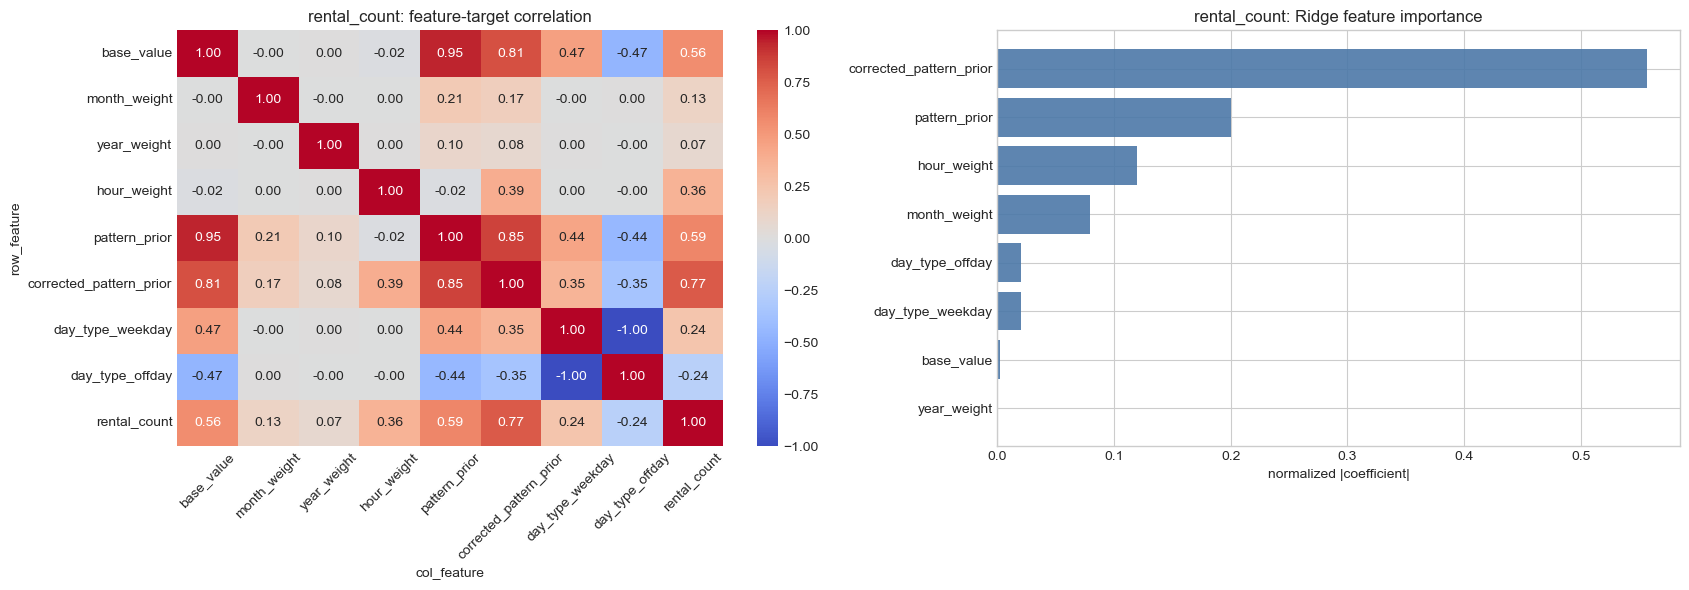

[rental_count] feature importance table


,feature,coefficient,importance_abs,importance_ratio
5,corrected_pattern_prior,1.4691,1.4691,0.5572
4,pattern_prior,-0.5287,0.5287,0.2005
3,hour_weight,-0.3144,0.3144,0.1193
1,month_weight,0.2101,0.2101,0.0797
7,day_type_offday,-0.0535,0.0535,0.0203
6,day_type_weekday,0.0535,0.0535,0.0203
0,base_value,-0.0069,0.0069,0.0026
2,year_weight,-0.0000,0.0000,0.0000


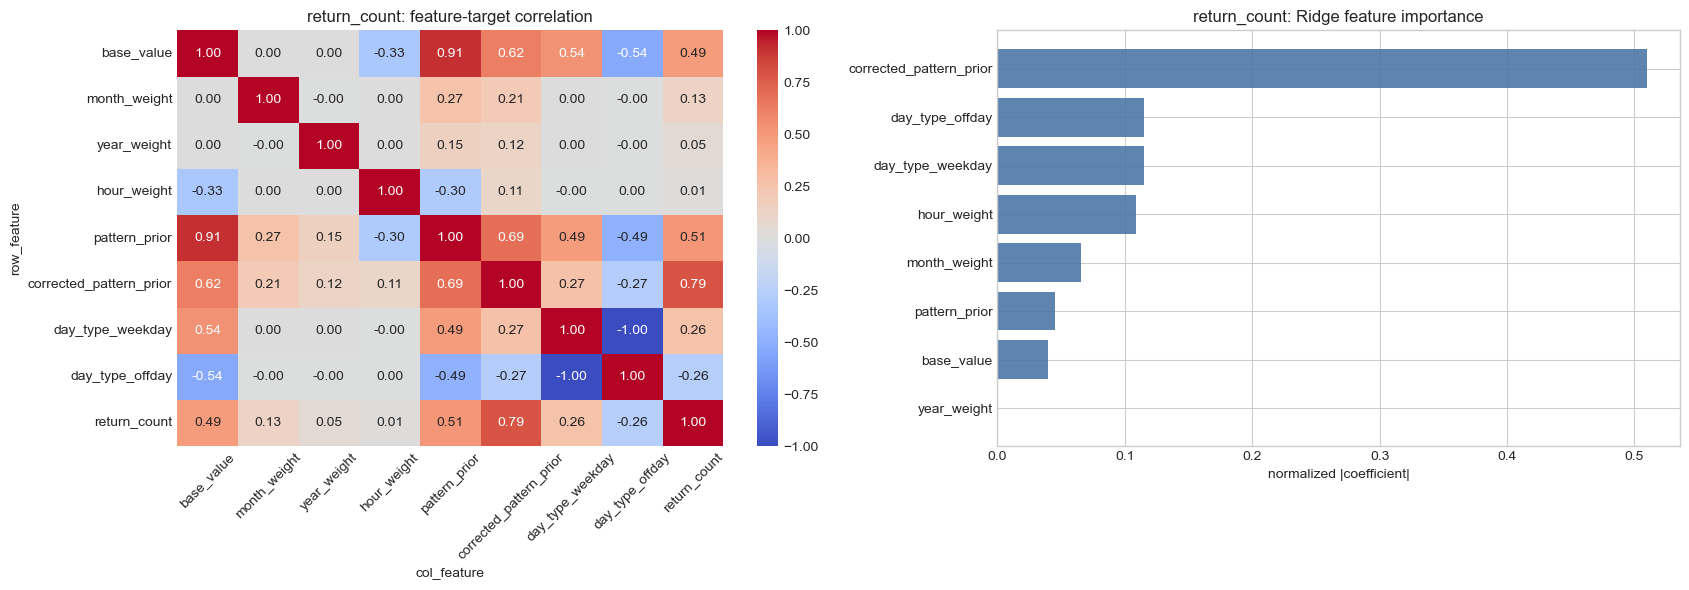

[return_count] feature importance table


,feature,coefficient,importance_abs,importance_ratio
13,corrected_pattern_prior,2.1940,2.1940,0.5103
15,day_type_offday,-0.4954,0.4954,0.1152
14,day_type_weekday,0.4954,0.4954,0.1152
11,hour_weight,-0.4675,0.4675,0.1087
9,month_weight,-0.2812,0.2812,0.0654
12,pattern_prior,-0.1954,0.1954,0.0454
8,base_value,-0.1704,0.1704,0.0396
10,year_weight,-0.0000,0.0000,0.0000


In [5]:
for target in target_cols:
    corr_matrix = feature_correlation_df[feature_correlation_df['target'] == target].pivot(index='row_feature', columns='col_feature', values='correlation')
    ordered_cols = [
        'base_value', 'month_weight', 'year_weight', 'hour_weight', 'pattern_prior', 'corrected_pattern_prior',
        'day_type_weekday', 'day_type_offday', target
    ]
    corr_matrix = corr_matrix.loc[ordered_cols, ordered_cols]

    importance_df = feature_importance_df[feature_importance_df['target'] == target].sort_values('importance_ratio', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0])
    axes[0].set_title(f'{target}: feature-target correlation')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    axes[1].barh(importance_df['feature'], importance_df['importance_ratio'], color='#4C78A8', alpha=0.9)
    axes[1].invert_yaxis()
    axes[1].set_title(f'{target}: Ridge feature importance')
    axes[1].set_xlabel('normalized |coefficient|')

    plt.tight_layout()
    plt.show()

    print(f'[{target}] feature importance table')
    display(importance_df[['feature', 'coefficient', 'importance_abs', 'importance_ratio']].round(4))


## Train Valid Test Performance Comparison

아래 섹션은 `rental_count`, `return_count`에 대해 `train`, `valid`, `test` 성능을 표와 그래프로 비교합니다.

- 지표: `RMSE`, `MAE`, `R^2`
- 타깃별 split 성능 비교
- 패턴 기반 회귀 모델의 일반화 수준 확인

,target,split,rmse,mae,r2
0,rental_count,train,2.0209,1.1681,0.5636
1,rental_count,valid,1.9730,1.1890,0.6640
2,rental_count,test,1.7215,1.0214,0.5848
3,return_count,train,2.3385,1.3829,0.6408
4,return_count,valid,2.4764,1.5107,0.6702
5,return_count,test,2.2219,1.2797,0.6441


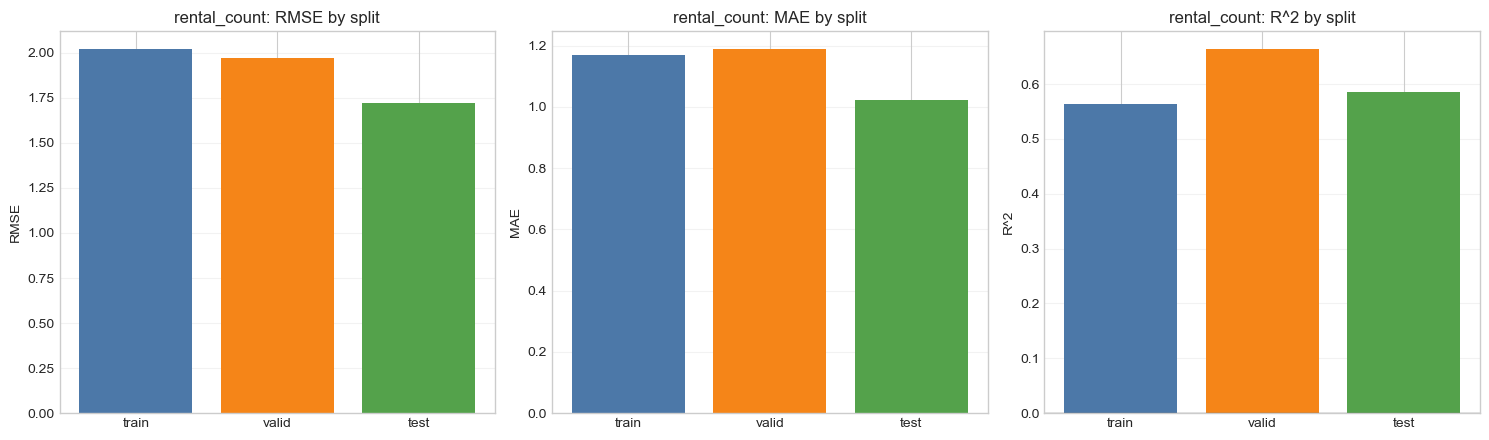

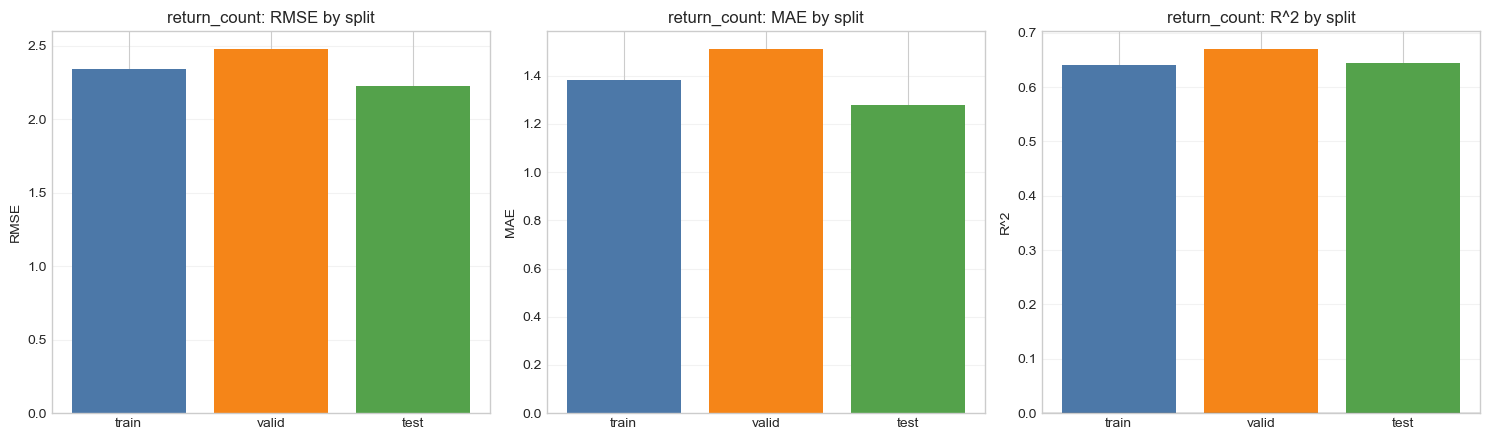

In [6]:
score_compare_df = ridge_metrics_df[ridge_metrics_df['target'].isin(target_cols)].copy()
score_compare_df['split'] = pd.Categorical(score_compare_df['split'], categories=['train', 'valid', 'test'], ordered=True)
score_compare_df = score_compare_df.sort_values(['target', 'split']).reset_index(drop=True)
display(score_compare_df[['target', 'split', 'rmse', 'mae', 'r2']].round(4))

for target in target_cols:
    target_scores = score_compare_df[score_compare_df['target'] == target].copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    axes[0].bar(target_scores['split'].astype(str), target_scores['rmse'], color=['#4C78A8', '#F58518', '#54A24B'])
    axes[0].set_title(f'{target}: RMSE by split')
    axes[0].set_ylabel('RMSE')

    axes[1].bar(target_scores['split'].astype(str), target_scores['mae'], color=['#4C78A8', '#F58518', '#54A24B'])
    axes[1].set_title(f'{target}: MAE by split')
    axes[1].set_ylabel('MAE')

    axes[2].bar(target_scores['split'].astype(str), target_scores['r2'], color=['#4C78A8', '#F58518', '#54A24B'])
    axes[2].axhline(0, color='black', linewidth=1, alpha=0.5)
    axes[2].set_title(f'{target}: R^2 by split')
    axes[2].set_ylabel('R^2')

    for ax in axes:
        ax.grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.show()


,target,alpha,rmse,mae,r2
5,rental_count,100.0000,1.9730,1.1890,0.6640
12,return_count,100.0000,2.4764,1.5107,0.6702


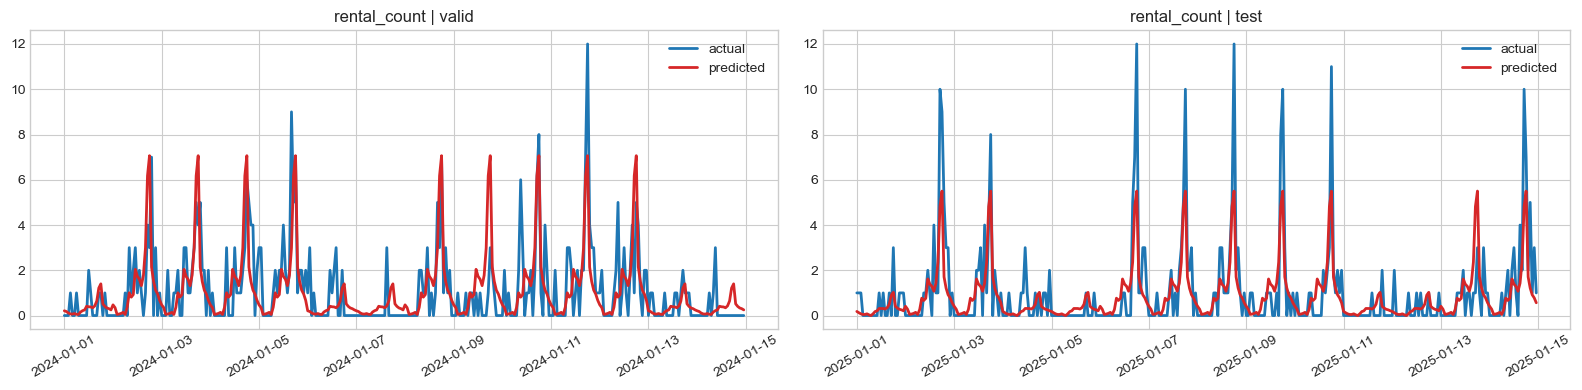

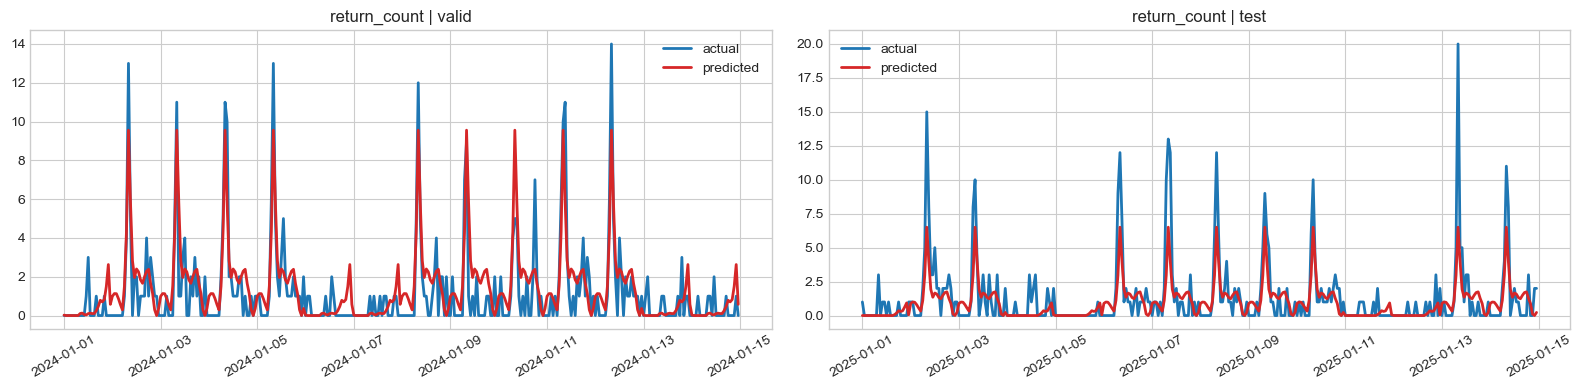

In [7]:
best_alpha_table = ridge_tuning_df.sort_values(['target', 'rmse']).groupby('target').head(1)
display(best_alpha_table.round(4))

for target in target_cols:
    target_pred = ridge_predictions_df[ridge_predictions_df['target'] == target].copy()
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    for ax, split_name in zip(axes, ['valid', 'test']):
        split_df = target_pred[target_pred['split'] == split_name].sort_values('time').head(24 * 14)
        ax.plot(split_df['time'], split_df['actual_value'], label='actual', linewidth=2, color='#1f77b4')
        ax.plot(split_df['time'], split_df['prediction'], label='predicted', linewidth=2, color='#d62728')
        ax.set_title(f'{target} | {split_name}')
        ax.tick_params(axis='x', rotation=30)
        ax.legend()
    plt.tight_layout()
    plt.show()


## Year Pattern Comparison And Error Diagnostics

아래 그래프는 `2023`, `2024`, `2025`의 실제값, 회귀식 기반 패턴값(`pattern_prior`), 그리고 머신러닝 예측값(`prediction`)을 한눈에 비교하기 위한 섹션입니다.

- 연도별 시간 패턴: 실제값 vs 회귀식 패턴값 vs ML 예측값
- 연도별 월 패턴: 실제값 vs 회귀식 패턴값 vs ML 예측값
- `2025 test` 시계열에서 실제값 vs 회귀식 패턴값 vs ML 예측값 비교
- `2025 test`에서 오차가 큰 시점 표시 및 월별/시간대별 평균 절대오차 확인

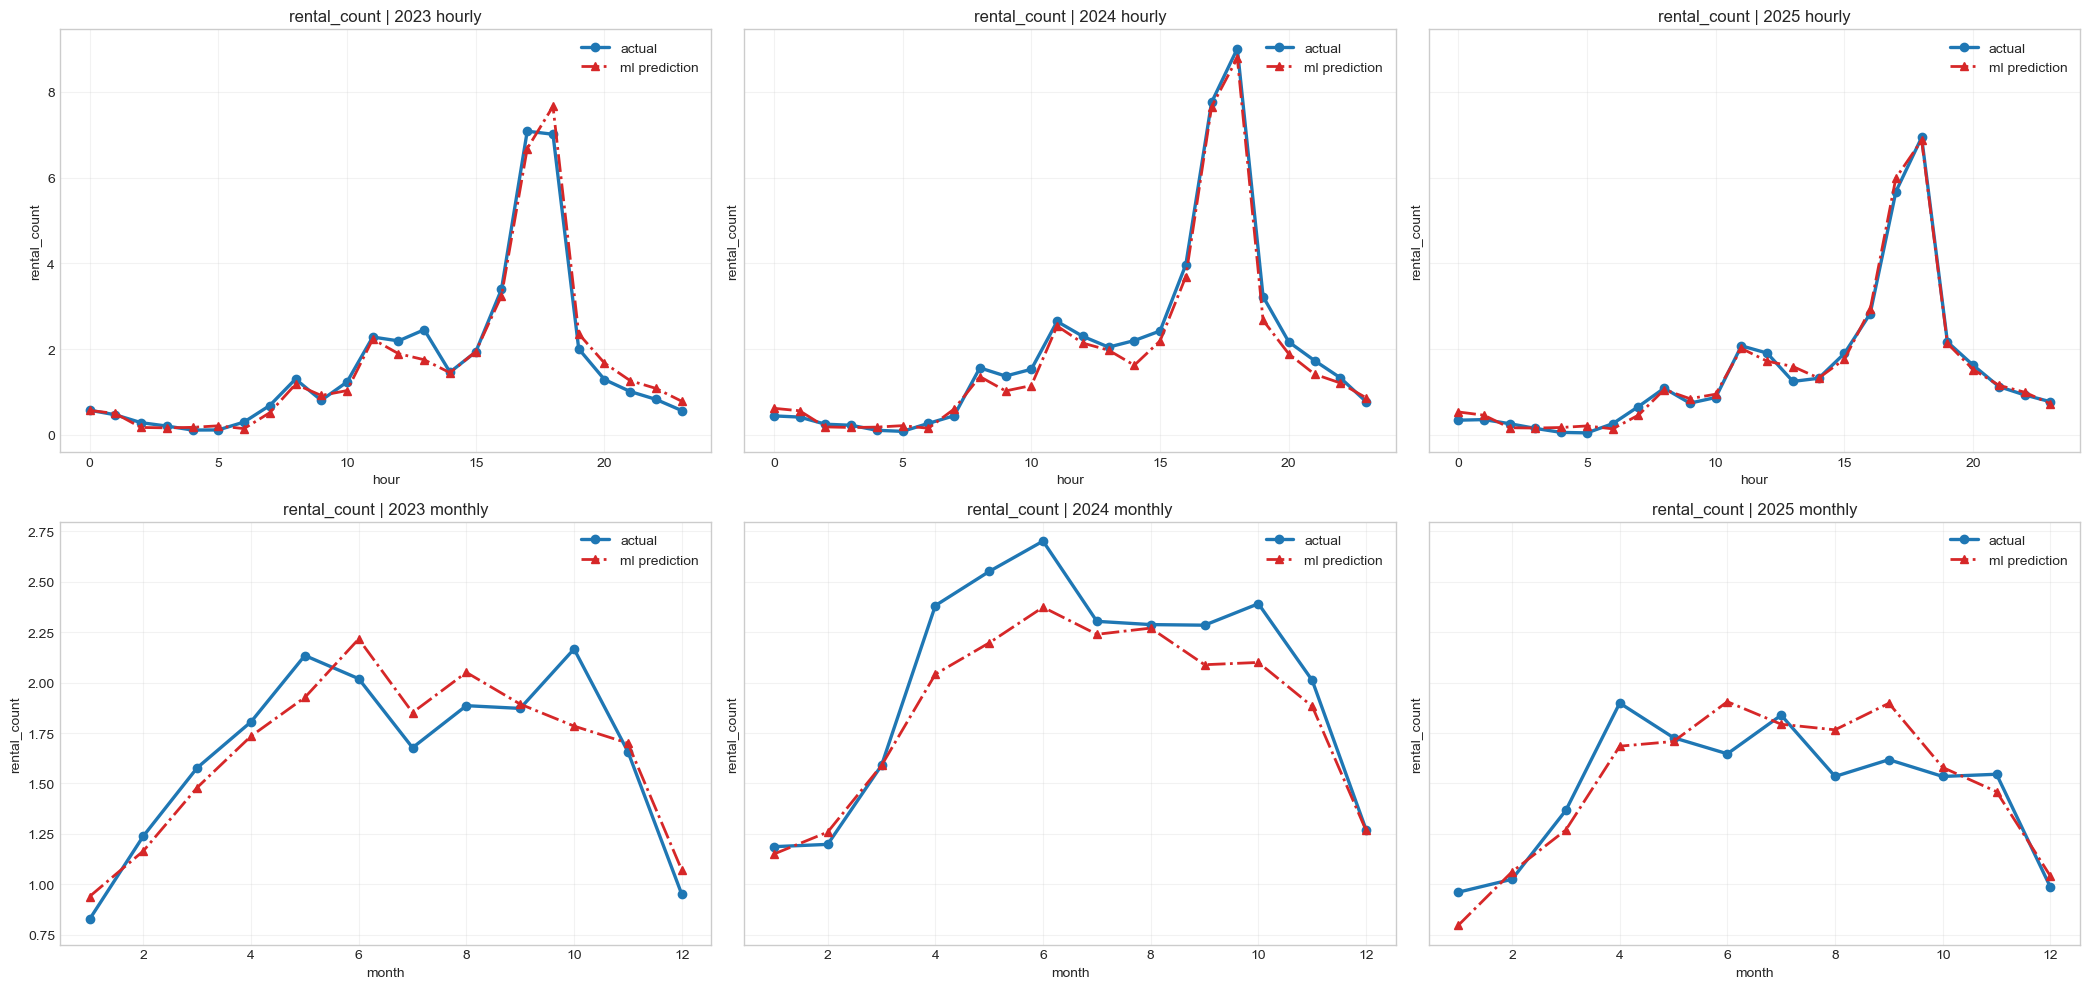

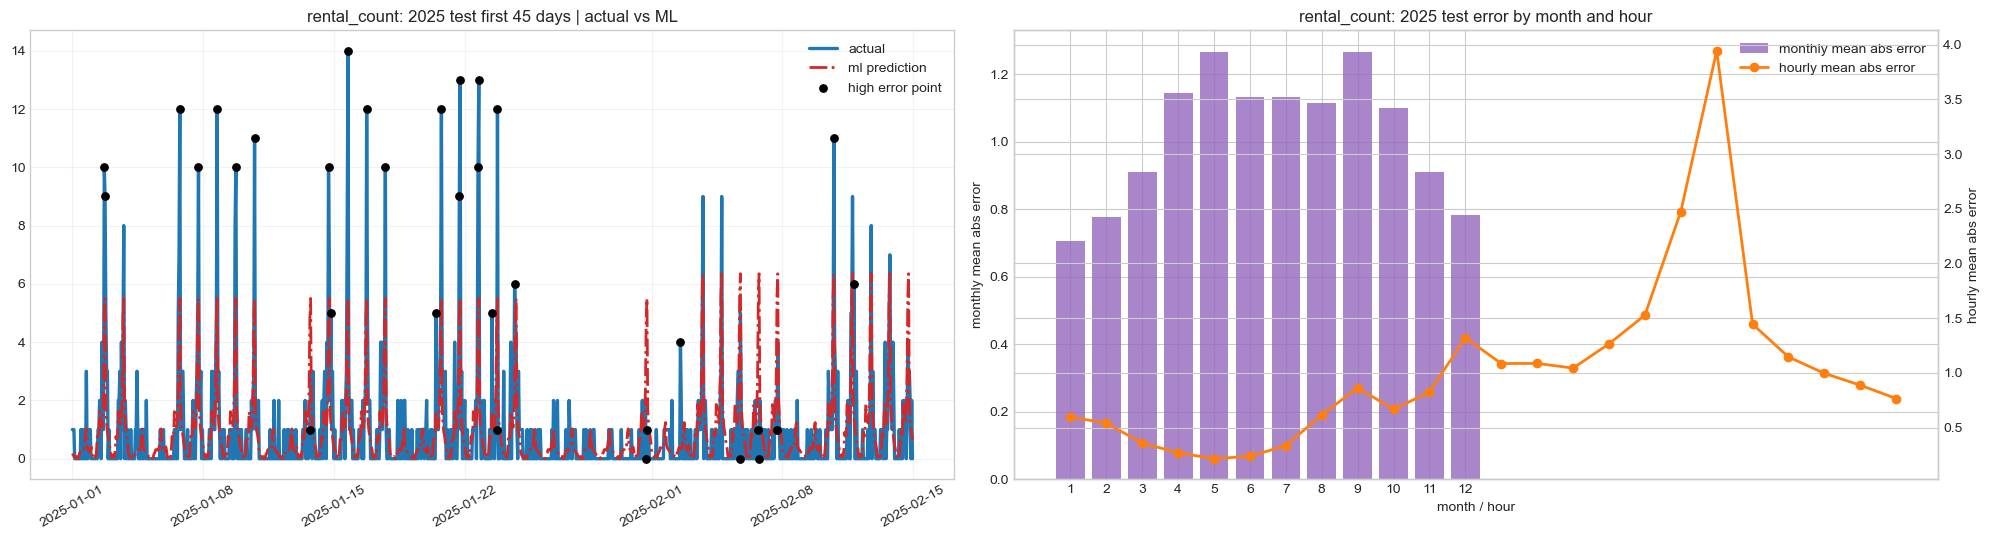

[rental_count] top 20 high-error points in 2025 test


,time,day_type,month,hour,actual_value,pattern_prior,prediction,abs_error
20747,2025-05-14 11:00:00,weekday,5,11,22,2.8776,3.1446,18.8554
20898,2025-05-20 18:00:00,weekday,5,18,28,4.4603,10.7998,17.2002
20729,2025-05-13 17:00:00,weekday,5,17,26,4.7149,9.4222,16.5778
22146,2025-07-11 18:00:00,weekday,7,18,24,4.2944,10.3834,13.6166
23082,2025-08-19 18:00:00,weekday,8,18,24,4.6029,11.1580,12.8420
22386,2025-07-21 18:00:00,weekday,7,18,23,4.2944,10.3834,12.6166
24762,2025-10-28 18:00:00,weekday,10,18,23,4.3982,10.6439,12.3561
20706,2025-05-12 18:00:00,weekday,5,18,23,4.4603,10.7998,12.2002
21642,2025-06-20 18:00:00,weekday,6,18,0,5.0007,12.1569,12.1569
23897,2025-09-22 17:00:00,weekday,9,17,21,4.8256,9.6505,11.3495


[rental_count] monthly mean absolute error in 2025 test


,month,abs_error
0,1,0.7055
1,2,0.7768
2,3,0.9094
3,4,1.1446
4,5,1.2666
5,6,1.1314
6,7,1.1335
7,8,1.1159
8,9,1.2669
9,10,1.1000


[rental_count] hourly mean absolute error in 2025 test


,hour,abs_error
0,0,0.5970
1,1,0.5405
2,2,0.3585
3,3,0.2705
4,4,0.2157
5,5,0.2381
6,6,0.3359
7,7,0.6156
8,8,0.8636
9,9,0.6673


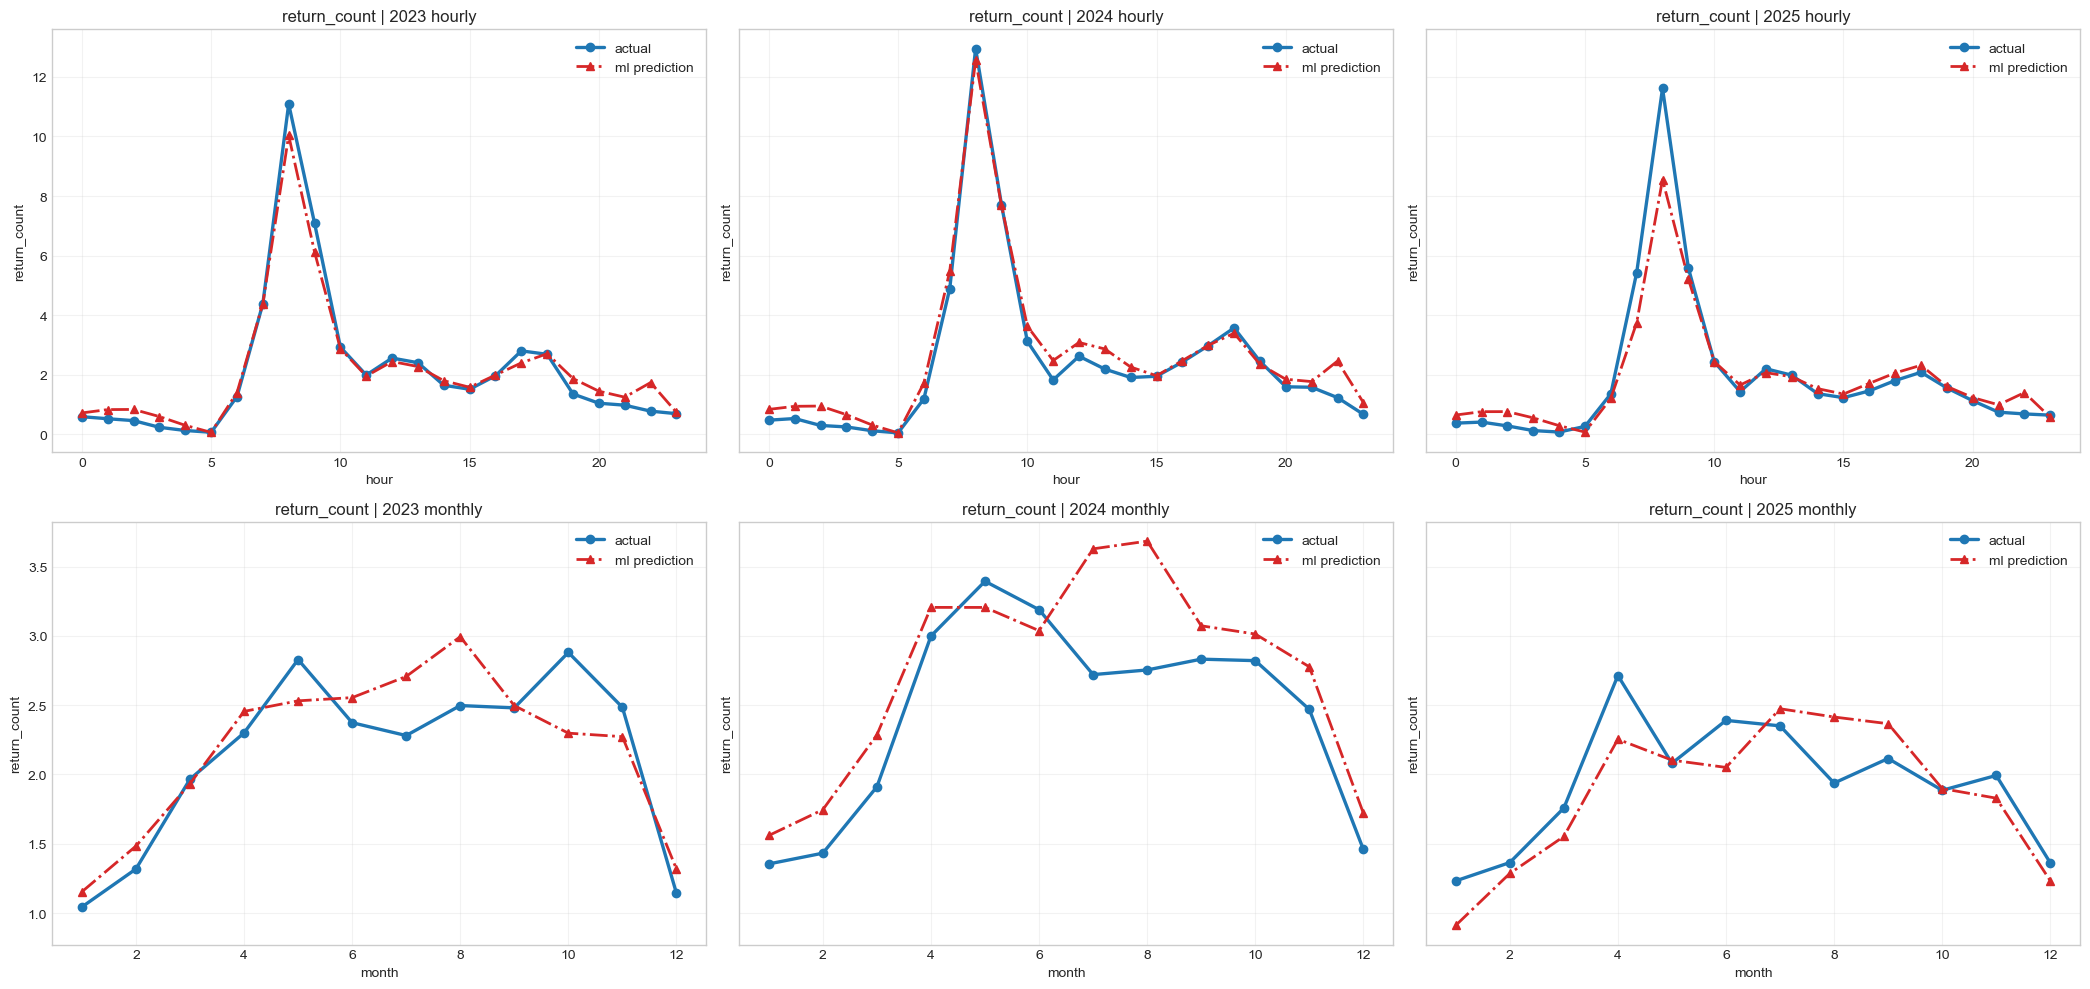

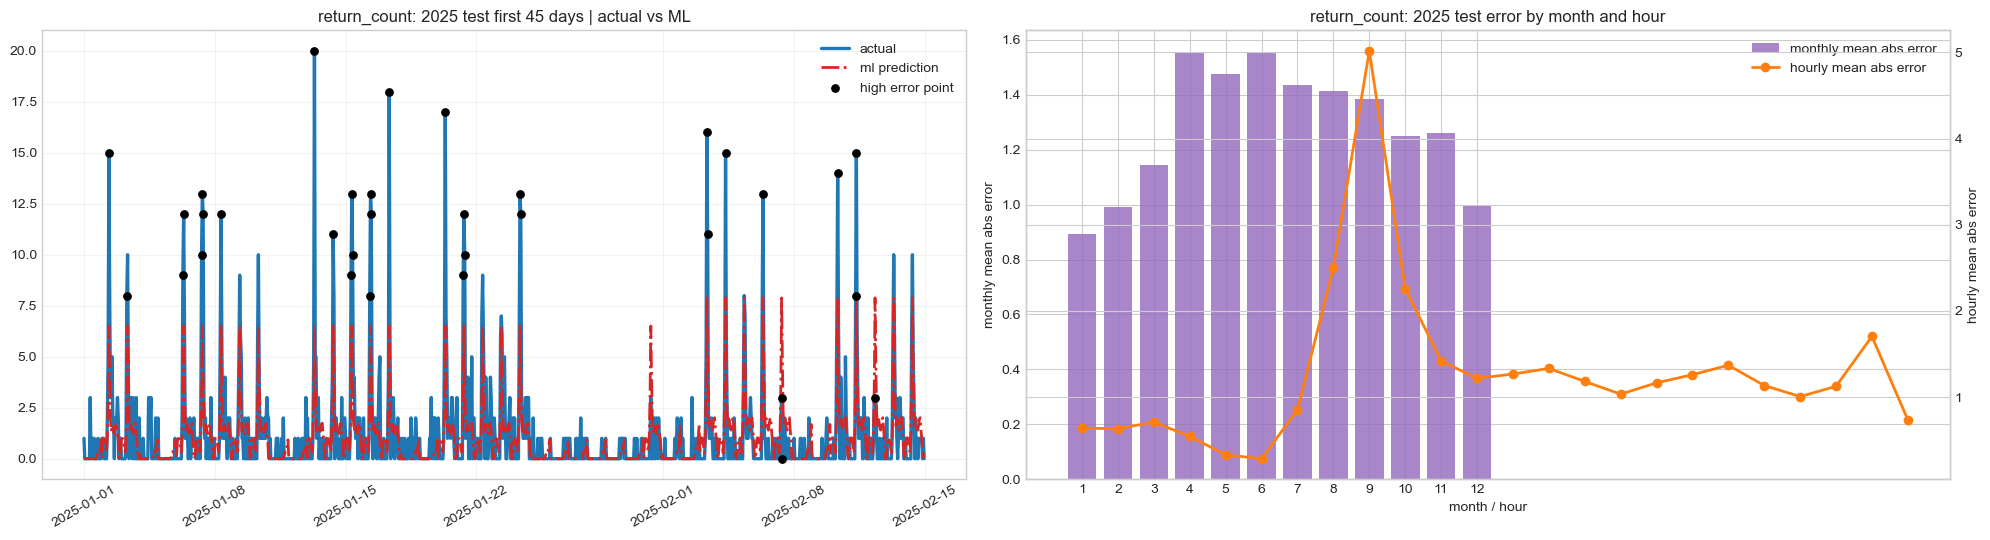

[return_count] top 20 high-error points in 2025 test


,time,day_type,month,hour,actual_value,pattern_prior,prediction,abs_error
47552,2025-06-04 08:00:00,weekday,6,8,43,5.0693,14.5738,28.4262
47672,2025-06-09 08:00:00,weekday,6,8,40,5.0693,14.5738,25.4262
46688,2025-04-29 08:00:00,weekday,4,8,36,5.0308,14.4601,21.5399
45992,2025-03-31 08:00:00,weekday,3,8,30,3.7455,10.6666,19.3334
47696,2025-06-10 08:00:00,weekday,6,8,33,5.0693,14.5738,18.4262
46256,2025-04-11 08:00:00,weekday,4,8,32,5.0308,14.4601,17.5399
47864,2025-06-17 08:00:00,weekday,6,8,32,5.0693,14.5738,17.4262
47024,2025-05-13 08:00:00,weekday,5,8,32,5.1362,14.7711,17.2289
49232,2025-08-13 08:00:00,weekday,8,8,0,5.9197,17.0838,17.0838
46232,2025-04-10 08:00:00,weekday,4,8,31,5.0308,14.4601,16.5399


[return_count] monthly mean absolute error in 2025 test


,month,abs_error
0,1,0.8915
1,2,0.9898
2,3,1.1428
3,4,1.5507
4,5,1.4753
5,6,1.5568
6,7,1.4351
7,8,1.4142
8,9,1.3864
9,10,1.2507


[return_count] hourly mean absolute error in 2025 test


,hour,abs_error
0,0,0.6393
1,1,0.6324
2,2,0.7097
3,3,0.5428
4,4,0.3294
5,5,0.2841
6,6,0.8523
7,7,2.5012
8,8,5.0183
9,9,2.2596


In [8]:
comparison_summary_rows = []
error_hotspot_rows = []

for target in target_cols:
    target_df = ridge_predictions_df[ridge_predictions_df['target'] == target].copy().sort_values('time')

    fig, axes = plt.subplots(2, 3, figsize=(21, 10), sharey='row')
    for col_idx, year in enumerate([2023, 2024, 2025]):
        year_df = target_df[target_df['year'] == year]

        yearly_hour = year_df.groupby('hour', as_index=False)[['actual_value', 'prediction']].mean()
        for _, row in yearly_hour.iterrows():
            comparison_summary_rows.append({'target': target, 'granularity': 'hour', 'year': year, 'key': int(row['hour']), 'series': 'actual_value', 'value': float(row['actual_value'])})
            comparison_summary_rows.append({'target': target, 'granularity': 'hour', 'year': year, 'key': int(row['hour']), 'series': 'prediction', 'value': float(row['prediction'])})
        axes[0, col_idx].plot(yearly_hour['hour'], yearly_hour['actual_value'], marker='o', linewidth=2.4, color='#1f77b4', label='actual')
        axes[0, col_idx].plot(yearly_hour['hour'], yearly_hour['prediction'], marker='^', linewidth=2.0, linestyle='-.', color='#d62728', label='ml prediction')
        axes[0, col_idx].set_title(f'{target} | {year} hourly')
        axes[0, col_idx].set_xlabel('hour')
        axes[0, col_idx].set_ylabel(target)
        axes[0, col_idx].grid(alpha=0.25)
        axes[0, col_idx].legend()

        yearly_month = year_df.groupby('month', as_index=False)[['actual_value', 'prediction']].mean()
        for _, row in yearly_month.iterrows():
            comparison_summary_rows.append({'target': target, 'granularity': 'month', 'year': year, 'key': int(row['month']), 'series': 'actual_value', 'value': float(row['actual_value'])})
            comparison_summary_rows.append({'target': target, 'granularity': 'month', 'year': year, 'key': int(row['month']), 'series': 'prediction', 'value': float(row['prediction'])})
        axes[1, col_idx].plot(yearly_month['month'], yearly_month['actual_value'], marker='o', linewidth=2.4, color='#1f77b4', label='actual')
        axes[1, col_idx].plot(yearly_month['month'], yearly_month['prediction'], marker='^', linewidth=2.0, linestyle='-.', color='#d62728', label='ml prediction')
        axes[1, col_idx].set_title(f'{target} | {year} monthly')
        axes[1, col_idx].set_xlabel('month')
        axes[1, col_idx].set_ylabel(target)
        axes[1, col_idx].grid(alpha=0.25)
        axes[1, col_idx].legend()

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
    test_target = target_df[target_df['split'] == 'test'].copy().sort_values('time')
    test_target['abs_error'] = (test_target['actual_value'] - test_target['prediction']).abs()
    error_cut = test_target['abs_error'].quantile(0.95)
    high_error = test_target[test_target['abs_error'] >= error_cut].copy()

    for row in high_error[['target', 'time', 'split', 'day_type', 'month', 'hour', 'actual_value', 'pattern_prior', 'prediction', 'abs_error']].to_dict('records'):
        error_hotspot_rows.append(row)

    sample_target = test_target.head(24 * 45)
    axes[0].plot(sample_target['time'], sample_target['actual_value'], linewidth=2.4, label='actual', color='#1f77b4')
    axes[0].plot(sample_target['time'], sample_target['prediction'], linewidth=2.0, linestyle='-.', label='ml prediction', color='#d62728')
    high_error_sample = high_error[high_error['time'].isin(sample_target['time'])]
    axes[0].scatter(high_error_sample['time'], high_error_sample['actual_value'], color='black', s=28, label='high error point', zorder=5)
    axes[0].set_title(f'{target}: 2025 test first 45 days | actual vs ML')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    monthly_error = test_target.groupby('month')['abs_error'].mean().reset_index()
    hourly_error = test_target.groupby('hour')['abs_error'].mean().reset_index()
    axes[1].bar(monthly_error['month'].astype(str), monthly_error['abs_error'], color='#9467bd', alpha=0.8, label='monthly mean abs error')
    ax2 = axes[1].twinx()
    ax2.plot(hourly_error['hour'], hourly_error['abs_error'], color='#ff7f0e', marker='o', linewidth=2, label='hourly mean abs error')
    axes[1].set_title(f'{target}: 2025 test error by month and hour')
    axes[1].set_xlabel('month / hour')
    axes[1].set_ylabel('monthly mean abs error')
    ax2.set_ylabel('hourly mean abs error')
    lines1, labels1 = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.tight_layout()
    plt.show()

    print(f'[{target}] top 20 high-error points in 2025 test')
    display(high_error[['time', 'day_type', 'month', 'hour', 'actual_value', 'pattern_prior', 'prediction', 'abs_error']].sort_values('abs_error', ascending=False).head(20))
    print(f'[{target}] monthly mean absolute error in 2025 test')
    display(monthly_error.round(4))
    print(f'[{target}] hourly mean absolute error in 2025 test')
    display(hourly_error.round(4))

comparison_summary_df = pd.DataFrame(comparison_summary_rows)
error_hotspot_df = pd.DataFrame(error_hotspot_rows).sort_values(['target', 'abs_error'], ascending=[True, False]).reset_index(drop=True)


In [9]:
holiday_df.to_csv(DATA_DIR / 'holiday_reference/station_2348_holiday_reference.csv', index=False, encoding='utf-8-sig')
formula_output_df.to_csv(DATA_DIR / 'formulas/station_2348_offday_hour_formulas.csv', index=False, encoding='utf-8-sig')
weight_output_df.to_csv(DATA_DIR / 'weights/station_2348_month_weights.csv', index=False, encoding='utf-8-sig')
ridge_tuning_df.to_csv(DATA_DIR / 'tuning/station_2348_offday_month_ridge_tuning.csv', index=False, encoding='utf-8-sig')
ridge_metrics_df.to_csv(DATA_DIR / 'metrics/station_2348_offday_month_ridge_metrics.csv', index=False, encoding='utf-8-sig')
ridge_predictions_df.to_csv(DATA_DIR / 'predictions/station_2348_offday_month_ridge_predictions_long.csv', index=False, encoding='utf-8-sig')
ridge_coefficients_df.to_csv(DATA_DIR / 'coefficients/station_2348_offday_month_ridge_coefficients.csv', index=False, encoding='utf-8-sig')
feature_correlation_df.to_csv(DATA_DIR / 'feature_analysis/station_2348_feature_correlation_long.csv', index=False, encoding='utf-8-sig')
feature_importance_df.to_csv(DATA_DIR / 'feature_analysis/station_2348_feature_importance.csv', index=False, encoding='utf-8-sig')
comparison_summary_df.to_csv(DATA_DIR / 'comparisons/station_2348_year_actual_vs_regression_vs_ml.csv', index=False, encoding='utf-8-sig')
error_hotspot_df.to_csv(DATA_DIR / 'comparisons/station_2348_2025_high_error_points.csv', index=False, encoding='utf-8-sig')

print('saved:')
print(DATA_DIR / 'holiday_reference/station_2348_holiday_reference.csv')
print(DATA_DIR / 'formulas/station_2348_offday_hour_formulas.csv')
print(DATA_DIR / 'weights/station_2348_month_weights.csv')
print(DATA_DIR / 'tuning/station_2348_offday_month_ridge_tuning.csv')
print(DATA_DIR / 'metrics/station_2348_offday_month_ridge_metrics.csv')
print(DATA_DIR / 'predictions/station_2348_offday_month_ridge_predictions_long.csv')
print(DATA_DIR / 'coefficients/station_2348_offday_month_ridge_coefficients.csv')
print(DATA_DIR / 'feature_analysis/station_2348_feature_correlation_long.csv')
print(DATA_DIR / 'feature_analysis/station_2348_feature_importance.csv')
print(DATA_DIR / 'comparisons/station_2348_year_actual_vs_regression_vs_ml.csv')
print(DATA_DIR / 'comparisons/station_2348_2025_high_error_points.csv')


saved:
..\Data\holiday_reference/station_2348_holiday_reference.csv
..\Data\formulas/station_2348_offday_hour_formulas.csv
..\Data\weights/station_2348_month_weights.csv
..\Data\tuning/station_2348_offday_month_ridge_tuning.csv
..\Data\metrics/station_2348_offday_month_ridge_metrics.csv
..\Data\predictions/station_2348_offday_month_ridge_predictions_long.csv
..\Data\coefficients/station_2348_offday_month_ridge_coefficients.csv
..\Data\feature_analysis/station_2348_feature_correlation_long.csv
..\Data\feature_analysis/station_2348_feature_importance.csv
..\Data\comparisons/station_2348_year_actual_vs_regression_vs_ml.csv
..\Data\comparisons/station_2348_2025_high_error_points.csv
